# 03 — Post-Training Model Evaluation
**Model**: ConvNeXt Small (convnext_small.fb_in22k_ft_in1k_384)  
**Task**: Multi-label chest X-ray classification (4 diseases)  
**Test AUC**: 0.826 | **Test F1-macro**: 0.393  

This notebook performs:
1. Classification report & confusion matrices
2. ROC / Precision-Recall curves
3. Grad-CAM++ visualisations (XAI)
4. Uncertainty analysis & heatmaps
5. Failure analysis

## 1. Setup

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn.functional as F
from pathlib import Path
from sklearn.metrics import (
    classification_report, multilabel_confusion_matrix,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    roc_auc_score, f1_score, accuracy_score
)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 150, "figure.facecolor": "white"})

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)  # Dataset uses relative paths from project root

CKPT_PATH = PROJECT_ROOT / "models" / "convnext_small_20260323_183605" / "convnext_small-epoch=20-val_f1_macro=0.4079.ckpt"
MANIFEST   = PROJECT_ROOT / "data" / "processed_1024_v2_4779b5" / "manifest.csv"
META_JSON  = PROJECT_ROOT / "models" / "best_models" / "xclinvision_convnext_small_vdc40_meta.json"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "evaluation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DISEASE_COLS = ["Cardiomegaly", "Aortic enlargement", "Pleural thickening", "Pulmonary fibrosis"]
IMAGE_SIZE = 1024
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Load model metadata
import json as _json
meta = _json.loads(META_JSON.read_text())
THRESHOLDS = meta["thresholds"]
print(f"Device: {DEVICE}")
print(f"Checkpoint: {CKPT_PATH.name}")
print(f"Thresholds: {THRESHOLDS}")

Device: cuda
Checkpoint: convnext_small-epoch=20-val_f1_macro=0.4079.ckpt
Thresholds: {'Cardiomegaly': 0.62, 'Aortic enlargement': 0.61, 'Pleural thickening': 0.75, 'Pulmonary fibrosis': 0.76}


## 2. Load Model & Run Inference

In [2]:
from xclinvision.modeling import build_model, get_model_normalization
from xclinvision.trainer import XClinVisionModel
from xclinvision.dataset import ChestXrayDataModule, get_val_transforms
from xclinvision.config import PipelineConfig

# Build base model and load checkpoint
base_model = build_model("convnext_small", num_classes=4, pretrained=False)
norm_stats = get_model_normalization("convnext_small")

pl_model = XClinVisionModel.load_from_checkpoint(
    str(CKPT_PATH),
    model=base_model,
    num_classes=4,
    map_location=DEVICE,
)
pl_model.eval()
pl_model.to(DEVICE)
model = pl_model.model
print(f"Model loaded: {sum(p.numel() for p in model.parameters())/1e6:.1f}M params")

Model loaded: 49.9M params


In [3]:
# Build data module for test set
config = PipelineConfig.from_yaml()
data_module = ChestXrayDataModule(
    manifest_path=str(MANIFEST),
    config=config,
    batch_size=8,
    num_workers=4,
    image_size=IMAGE_SIZE,
    mean=norm_stats["mean"],
    std=norm_stats["std"],
)
data_module.setup(stage="test")
test_loader = data_module.test_dataloader()
print(f"Test samples: {len(data_module.test_dataset)}")

Test samples: 2152


In [4]:
# Collect predictions
all_probs, all_targets = [], []

with torch.no_grad():
    for batch in test_loader:
        images, targets = batch
        images = images.to(DEVICE)
        logits = model(images)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)
        all_targets.append(targets.numpy())

y_probs = np.concatenate(all_probs, axis=0)
y_true  = np.concatenate(all_targets, axis=0)

# Apply optimised thresholds
thresh_arr = np.array([THRESHOLDS[c] for c in DISEASE_COLS])
y_pred = (y_probs >= thresh_arr).astype(int)

# Also default 0.5 threshold for comparison
y_pred_default = (y_probs >= 0.5).astype(int)

print(f"Predictions collected: {y_probs.shape}")
print(f"Positive predictions (optimised thresholds): {y_pred.sum(axis=0)}")
print(f"Positive predictions (default 0.5):          {y_pred_default.sum(axis=0)}")

Predictions collected: (2152, 4)
Positive predictions (optimised thresholds): [319 361  90  57]
Positive predictions (default 0.5):          [528 558 789 679]


## 3. Classification Report

In [5]:
report = classification_report(
    y_true, y_pred, target_names=DISEASE_COLS, zero_division=0, output_dict=True
)
report_str = classification_report(
    y_true, y_pred, target_names=DISEASE_COLS, zero_division=0
)
print("Classification Report (optimised thresholds):")
print(report_str)

# Save to file
(OUTPUT_DIR / "classification_report.txt").write_text(report_str)

Classification Report (optimised thresholds):
                    precision    recall  f1-score   support

      Cardiomegaly       0.48      0.56      0.52       272
Aortic enlargement       0.61      0.62      0.62       352
Pleural thickening       0.38      0.26      0.31       132
Pulmonary fibrosis       0.37      0.14      0.20       152

         micro avg       0.52      0.47      0.49       908
         macro avg       0.46      0.40      0.41       908
      weighted avg       0.50      0.47      0.47       908
       samples avg       0.10      0.11      0.10       908



542

### 3.1 Per-Class Confusion Matrices

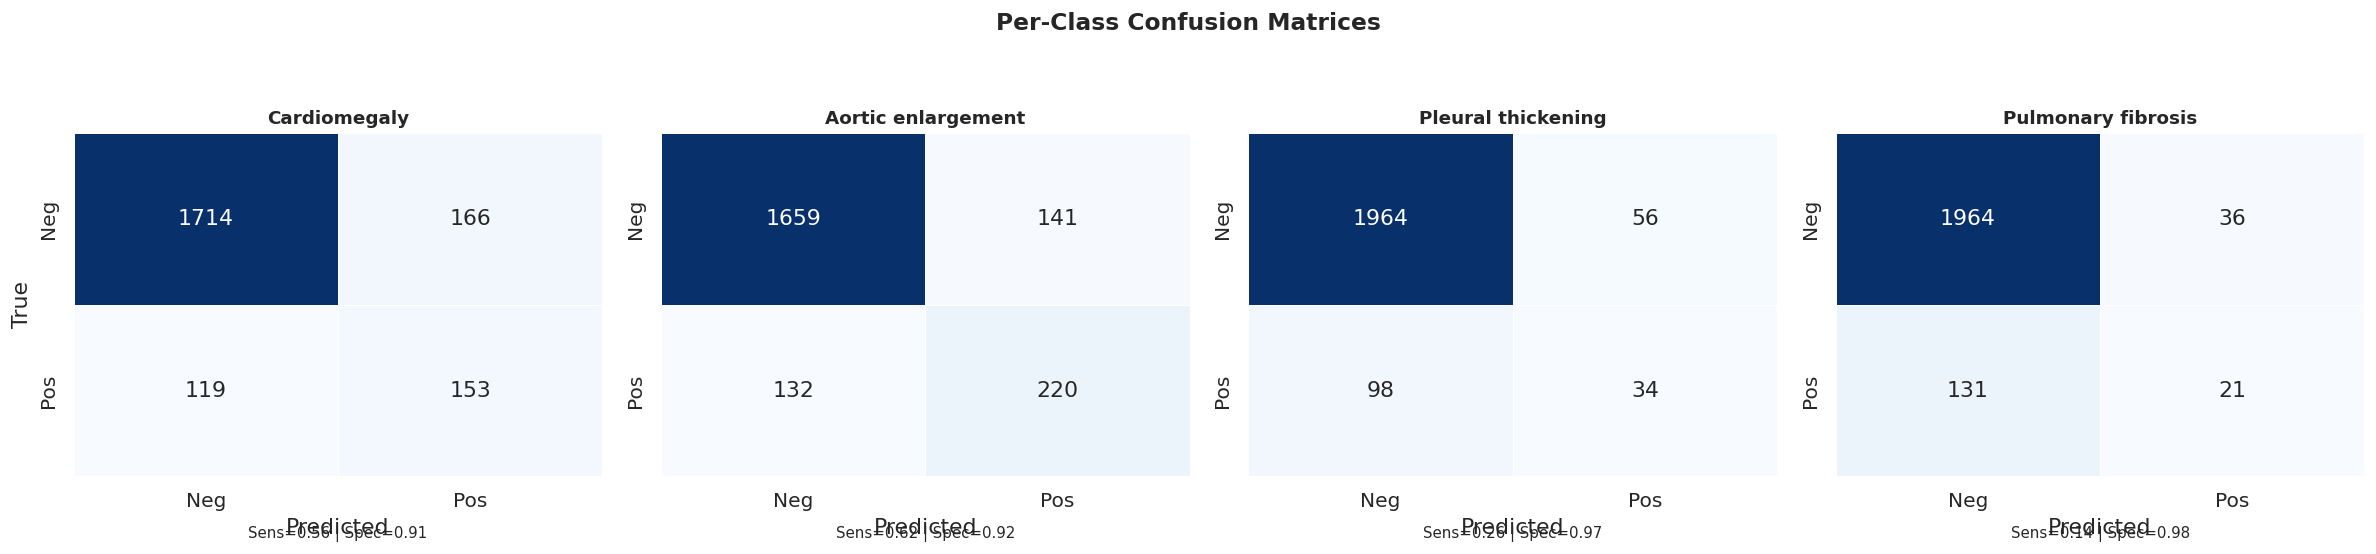

In [6]:
mcm = multilabel_confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for i, (cls, cm) in enumerate(zip(DISEASE_COLS, mcm)):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"],
                linewidths=0.5, cbar=False)
    axes[i].set_title(f"{cls}", fontweight="bold", fontsize=11)
    axes[i].set_ylabel("True" if i == 0 else "")
    axes[i].set_xlabel("Predicted")

    # Compute per-class metrics
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn + 1e-8)
    spec = tn / (tn + fp + 1e-8)
    axes[i].text(0.5, -0.18, f"Sens={sens:.2f} | Spec={spec:.2f}",
                 transform=axes[i].transAxes, ha="center", fontsize=9)

fig.suptitle("Per-Class Confusion Matrices", fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "confusion_matrices.png"), bbox_inches="tight", dpi=150)
plt.show()

## 4. ROC & Precision-Recall Curves

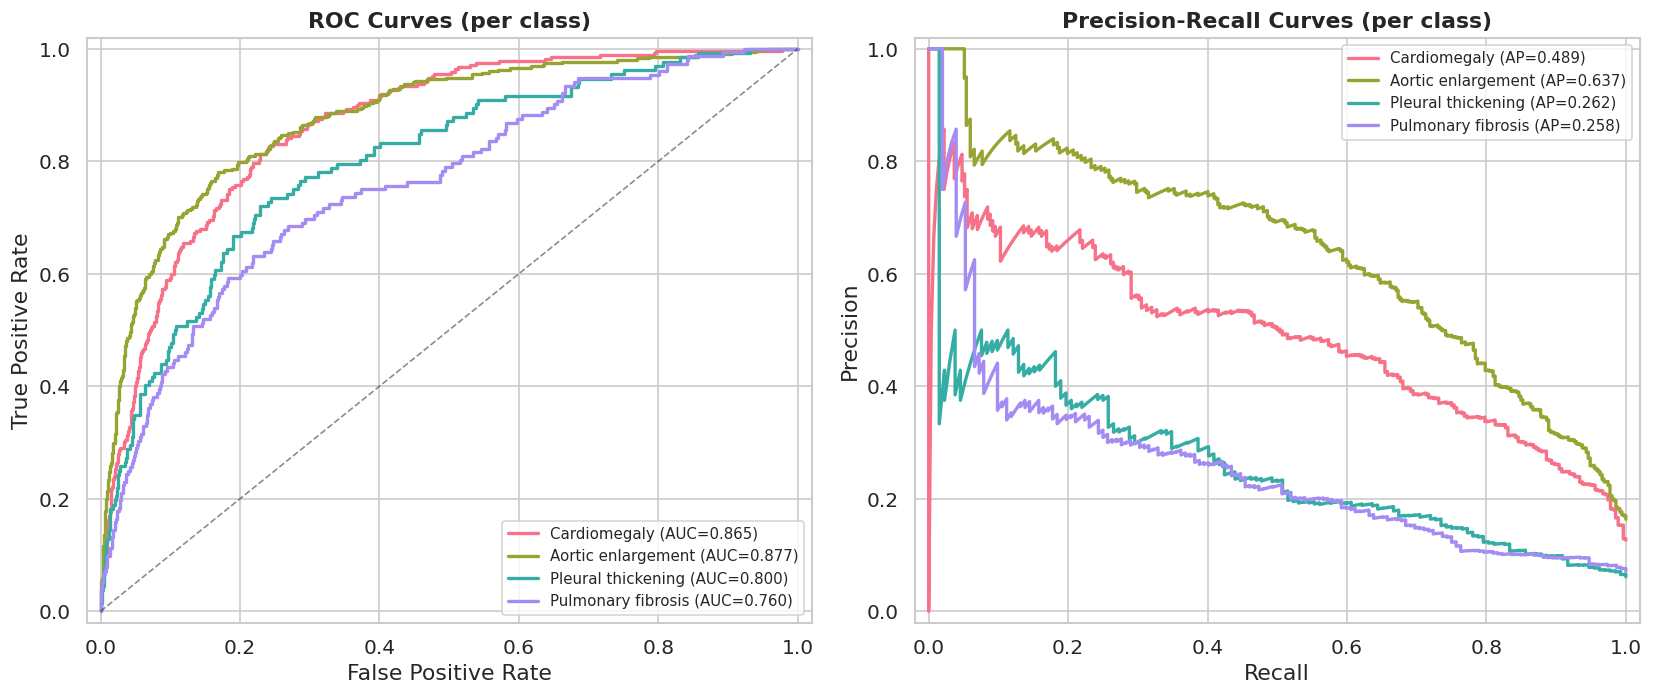

Macro AUC: 0.8255
  Cardiomegaly: AUC=0.8650
  Aortic enlargement: AUC=0.8773
  Pleural thickening: AUC=0.8000
  Pulmonary fibrosis: AUC=0.7598


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = sns.color_palette("husl", n_colors=4)

# ROC curves
for i, cls in enumerate(DISEASE_COLS):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_probs[:, i])
    roc_auc_val = auc(fpr, tpr)
    ax1.plot(fpr, tpr, color=colors[i], lw=2,
             label=f"{cls} (AUC={roc_auc_val:.3f})")

ax1.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curves (per class)", fontweight="bold")
ax1.legend(loc="lower right", fontsize=9)
ax1.set_xlim([-0.02, 1.02])
ax1.set_ylim([-0.02, 1.02])

# PR curves
for i, cls in enumerate(DISEASE_COLS):
    precision, recall, _ = precision_recall_curve(y_true[:, i], y_probs[:, i])
    ap = average_precision_score(y_true[:, i], y_probs[:, i])
    ax2.plot(recall, precision, color=colors[i], lw=2,
             label=f"{cls} (AP={ap:.3f})")

ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curves (per class)", fontweight="bold")
ax2.legend(loc="upper right", fontsize=9)
ax2.set_xlim([-0.02, 1.02])
ax2.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "roc_pr_curves.png"), bbox_inches="tight", dpi=150)
plt.show()

# Print overall AUC
macro_auc = roc_auc_score(y_true, y_probs, average="macro")
print(f"Macro AUC: {macro_auc:.4f}")
for i, cls in enumerate(DISEASE_COLS):
    print(f"  {cls}: AUC={roc_auc_score(y_true[:, i], y_probs[:, i]):.4f}")

## 5. Grad-CAM++ Visualisations
Generate Grad-CAM++ heatmaps for sample images from each disease class.

In [8]:
from xclinvision.xai import GradCAMPlusPlus, create_overlay, ExplainabilityEngine
import cv2

# Resolve target layer for ConvNeXt Small
target_layer = None
for name, module in model.named_modules():
    if "stages" in name and "blocks" in name:
        target_layer = module
# Use the last conv2d as fallback
if target_layer is None:
    for m in model.modules():
        if isinstance(m, torch.nn.Conv2d):
            target_layer = m

print(f"Grad-CAM++ target layer: {type(target_layer).__name__}")

gradcam = GradCAMPlusPlus(model, target_layer)

Grad-CAM++ target layer: DropPath


In [9]:
# Get sample images from the test set for each disease
manifest_df = pd.read_csv(MANIFEST)
test_manifest = manifest_df[manifest_df["split"] == "test"]

def load_processed_image(filepath):
    """Load preprocessed PNG image."""
    img = cv2.imread(str(PROJECT_ROOT / filepath))
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def preprocess_for_model(img, size=IMAGE_SIZE):
    """Preprocess image for model input."""
    img_resized = cv2.resize(img, (size, size))
    img_float = img_resized.astype(np.float32) / 255.0
    mean = np.array(norm_stats["mean"], dtype=np.float32)
    std  = np.array(norm_stats["std"], dtype=np.float32)
    normalised = (img_float - mean) / std
    tensor = torch.from_numpy(normalised).permute(2, 0, 1).unsqueeze(0).float()
    return tensor.to(DEVICE)

# Pick 2 samples per disease from test set
rng = np.random.RandomState(42)
samples_per_class = {}
for i, cls in enumerate(DISEASE_COLS):
    positive = test_manifest[test_manifest[cls] == 1]
    if len(positive) > 0:
        idx = rng.choice(len(positive), size=min(2, len(positive)), replace=False)
        samples_per_class[cls] = positive.iloc[idx]
    else:
        samples_per_class[cls] = pd.DataFrame()

print("Samples selected per class:")
for cls, sub in samples_per_class.items():
    print(f"  {cls}: {len(sub)} images")

Samples selected per class:
  Cardiomegaly: 2 images
  Aortic enlargement: 2 images
  Pleural thickening: 2 images
  Pulmonary fibrosis: 2 images


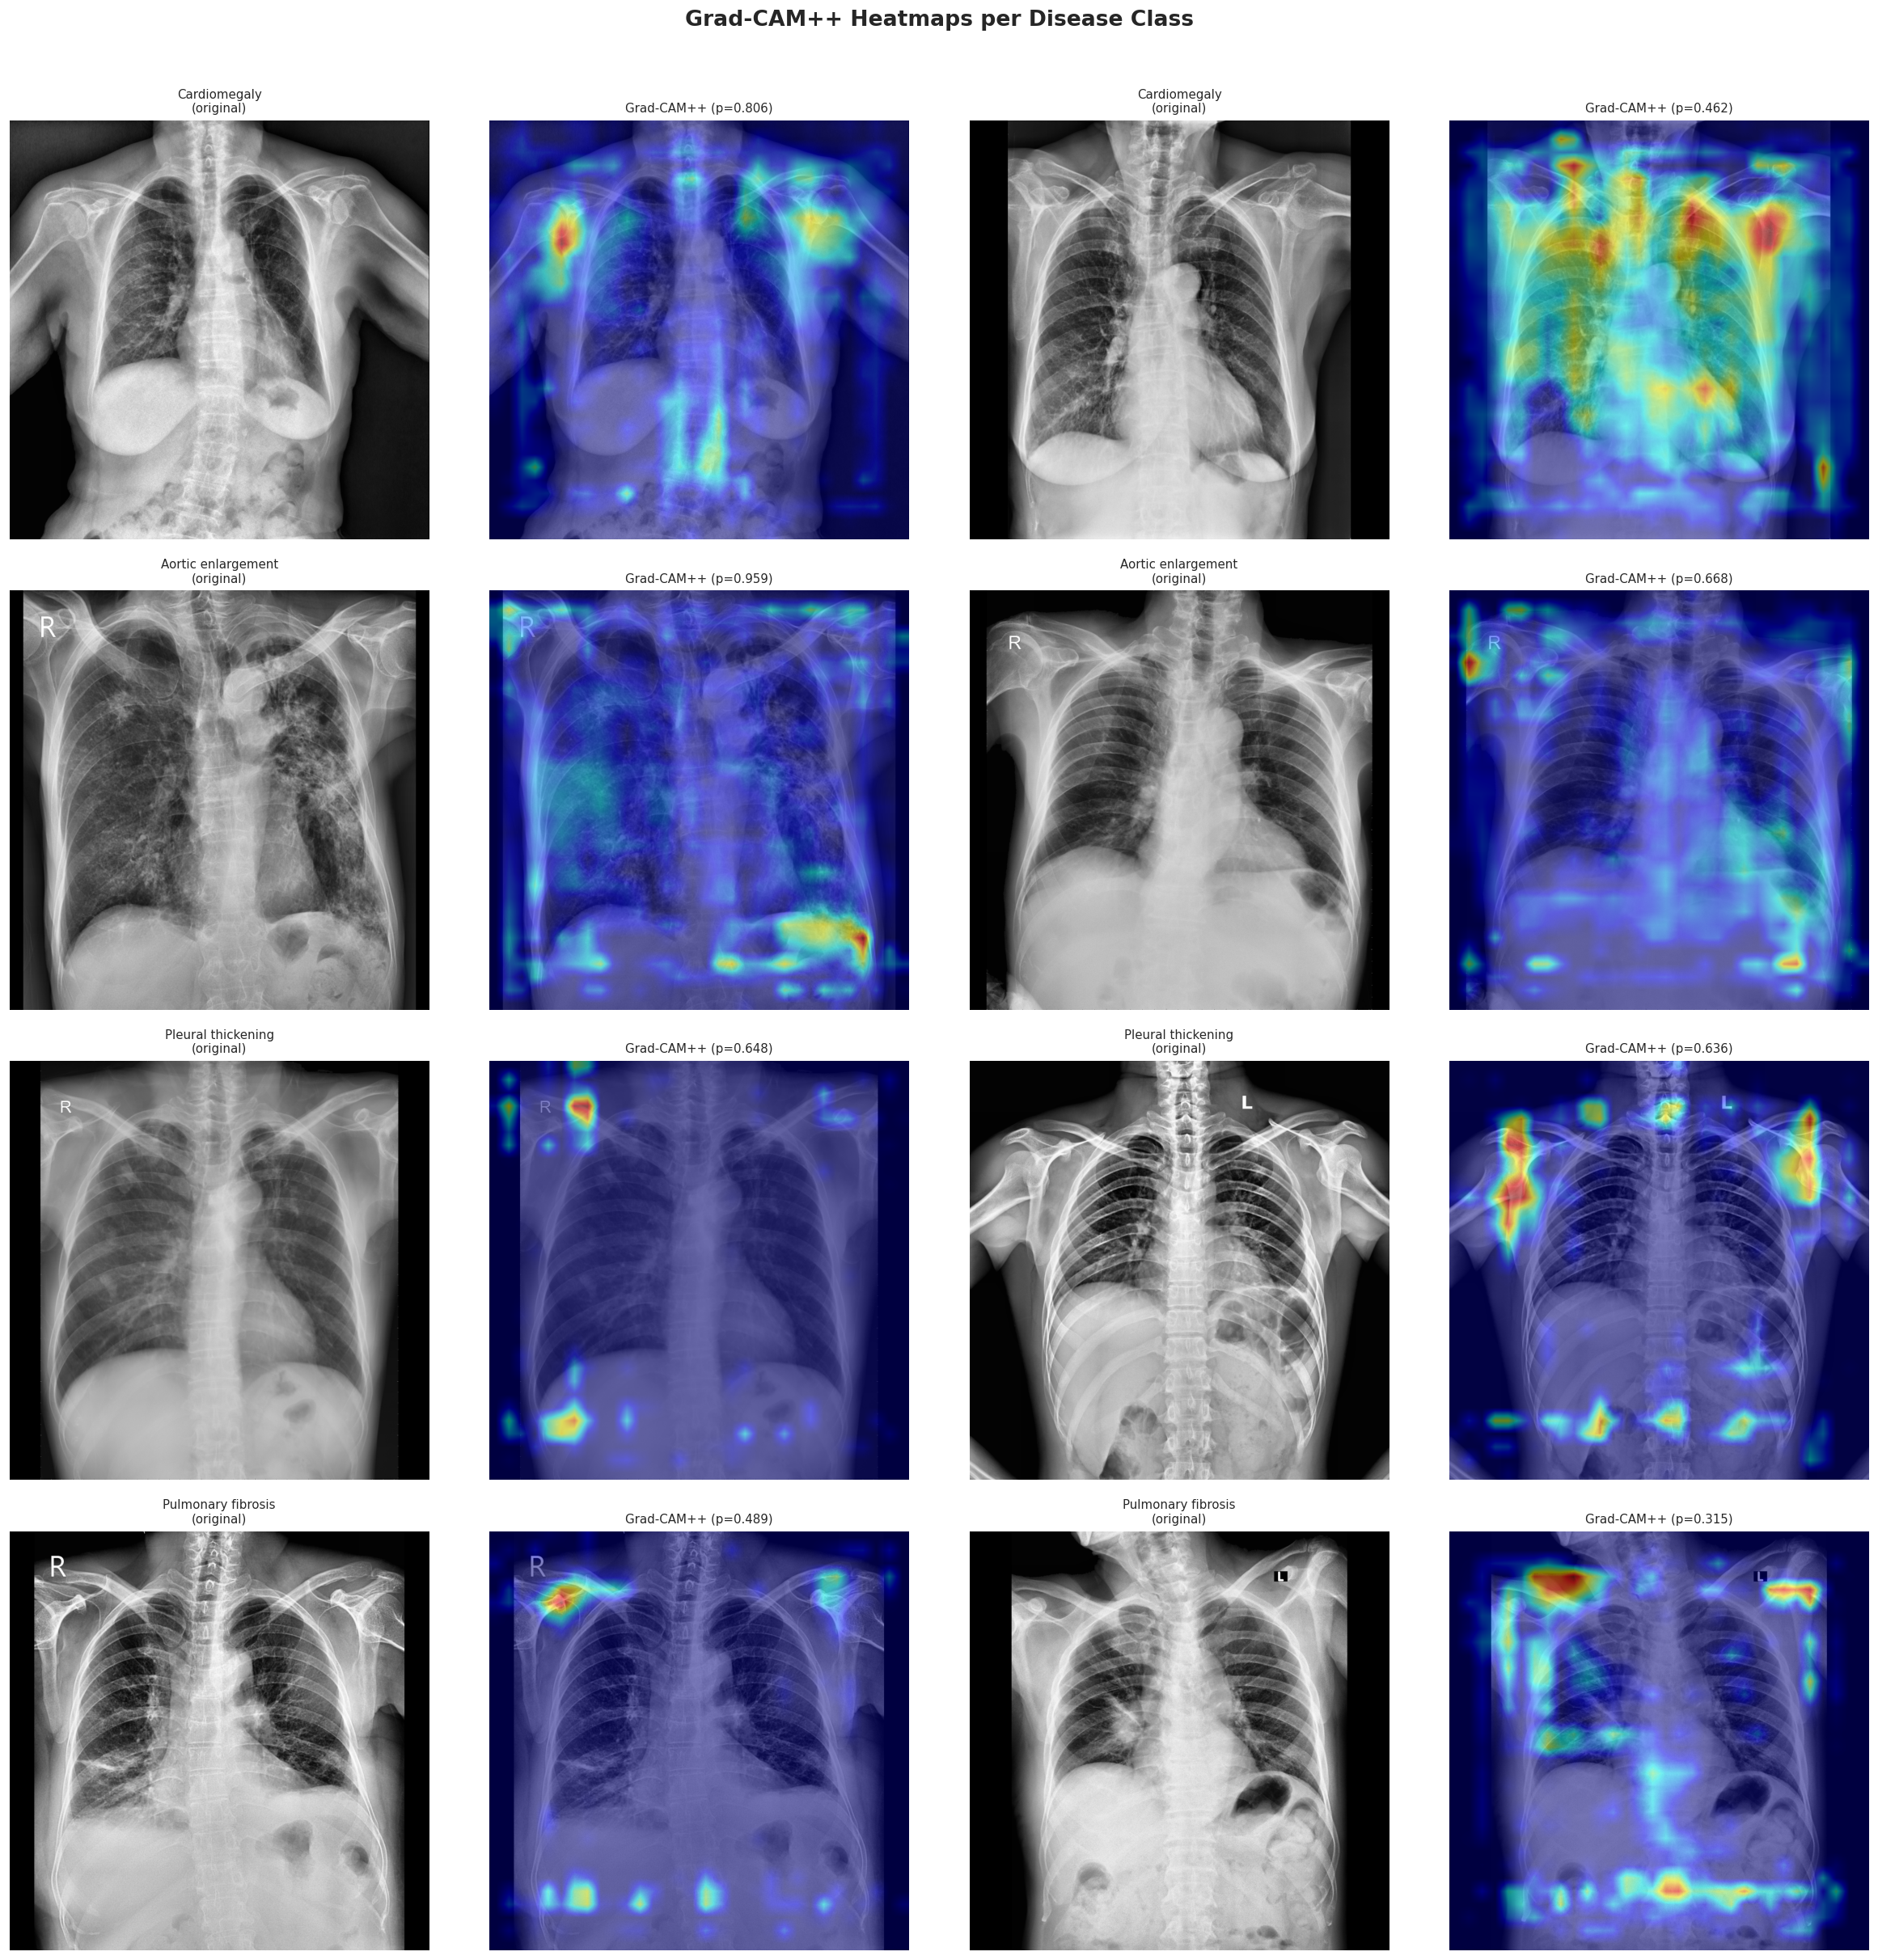

In [10]:
# Generate and display Grad-CAM++ heatmaps
fig, axes = plt.subplots(4, 4, figsize=(20, 20))  # 4 classes × (2 original + 2 heatmap)

for row, cls in enumerate(DISEASE_COLS):
    samples = samples_per_class[cls]
    for col_pair in range(min(2, len(samples))):
        sample = samples.iloc[col_pair]
        filepath = sample["filepath_processed"]
        img = load_processed_image(filepath)
        if img is None:
            continue
        
        input_tensor = preprocess_for_model(img)
        cls_idx = DISEASE_COLS.index(cls)
        
        try:
            cam, predicted_class = gradcam.generate(input_tensor, target_class=cls_idx)
            overlay = create_overlay(img, cam, alpha=0.5)
        except Exception as e:
            print(f"  Grad-CAM failed for {cls}: {e}")
            cam = np.zeros(img.shape[:2])
            overlay = img
        
        # Original image
        ax_orig = axes[row, col_pair * 2]
        ax_orig.imshow(img)
        ax_orig.set_title(f"{cls}\n(original)", fontsize=9)
        ax_orig.axis("off")
        
        # Grad-CAM overlay
        ax_cam = axes[row, col_pair * 2 + 1]
        ax_cam.imshow(overlay)
        prob_val = float(torch.sigmoid(model(input_tensor))[0, cls_idx].detach().cpu())
        ax_cam.set_title(f"Grad-CAM++ (p={prob_val:.3f})", fontsize=9)
        ax_cam.axis("off")

fig.suptitle("Grad-CAM++ Heatmaps per Disease Class", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "gradcam_heatmaps.png"), bbox_inches="tight", dpi=150)
plt.show()

gradcam.remove_hooks()

## 6. Uncertainty Analysis
Analyse model confidence and identify uncertain predictions.

In [11]:
# Entropy-based uncertainty for multi-label sigmoid outputs
# H(p) = - p*log(p) - (1-p)*log(1-p)   for each class
eps = 1e-7
entropy_per_class = -(y_probs * np.log(y_probs + eps) + (1 - y_probs) * np.log(1 - y_probs + eps))
mean_entropy = entropy_per_class.mean(axis=1)  # per-sample average entropy
max_entropy = np.log(2)  # max entropy for binary is ln(2)

# Normalised uncertainty ∈ [0, 1]
uncertainty = mean_entropy / max_entropy

print(f"Uncertainty stats:")
print(f"  Mean:   {uncertainty.mean():.4f}")
print(f"  Median: {np.median(uncertainty):.4f}")
print(f"  Std:    {uncertainty.std():.4f}")
print(f"  Min:    {uncertainty.min():.4f}")
print(f"  Max:    {uncertainty.max():.4f}")

Uncertainty stats:
  Mean:   0.8889
  Median: 0.9027
  Std:    0.0815
  Min:    0.1918
  Max:    0.9988


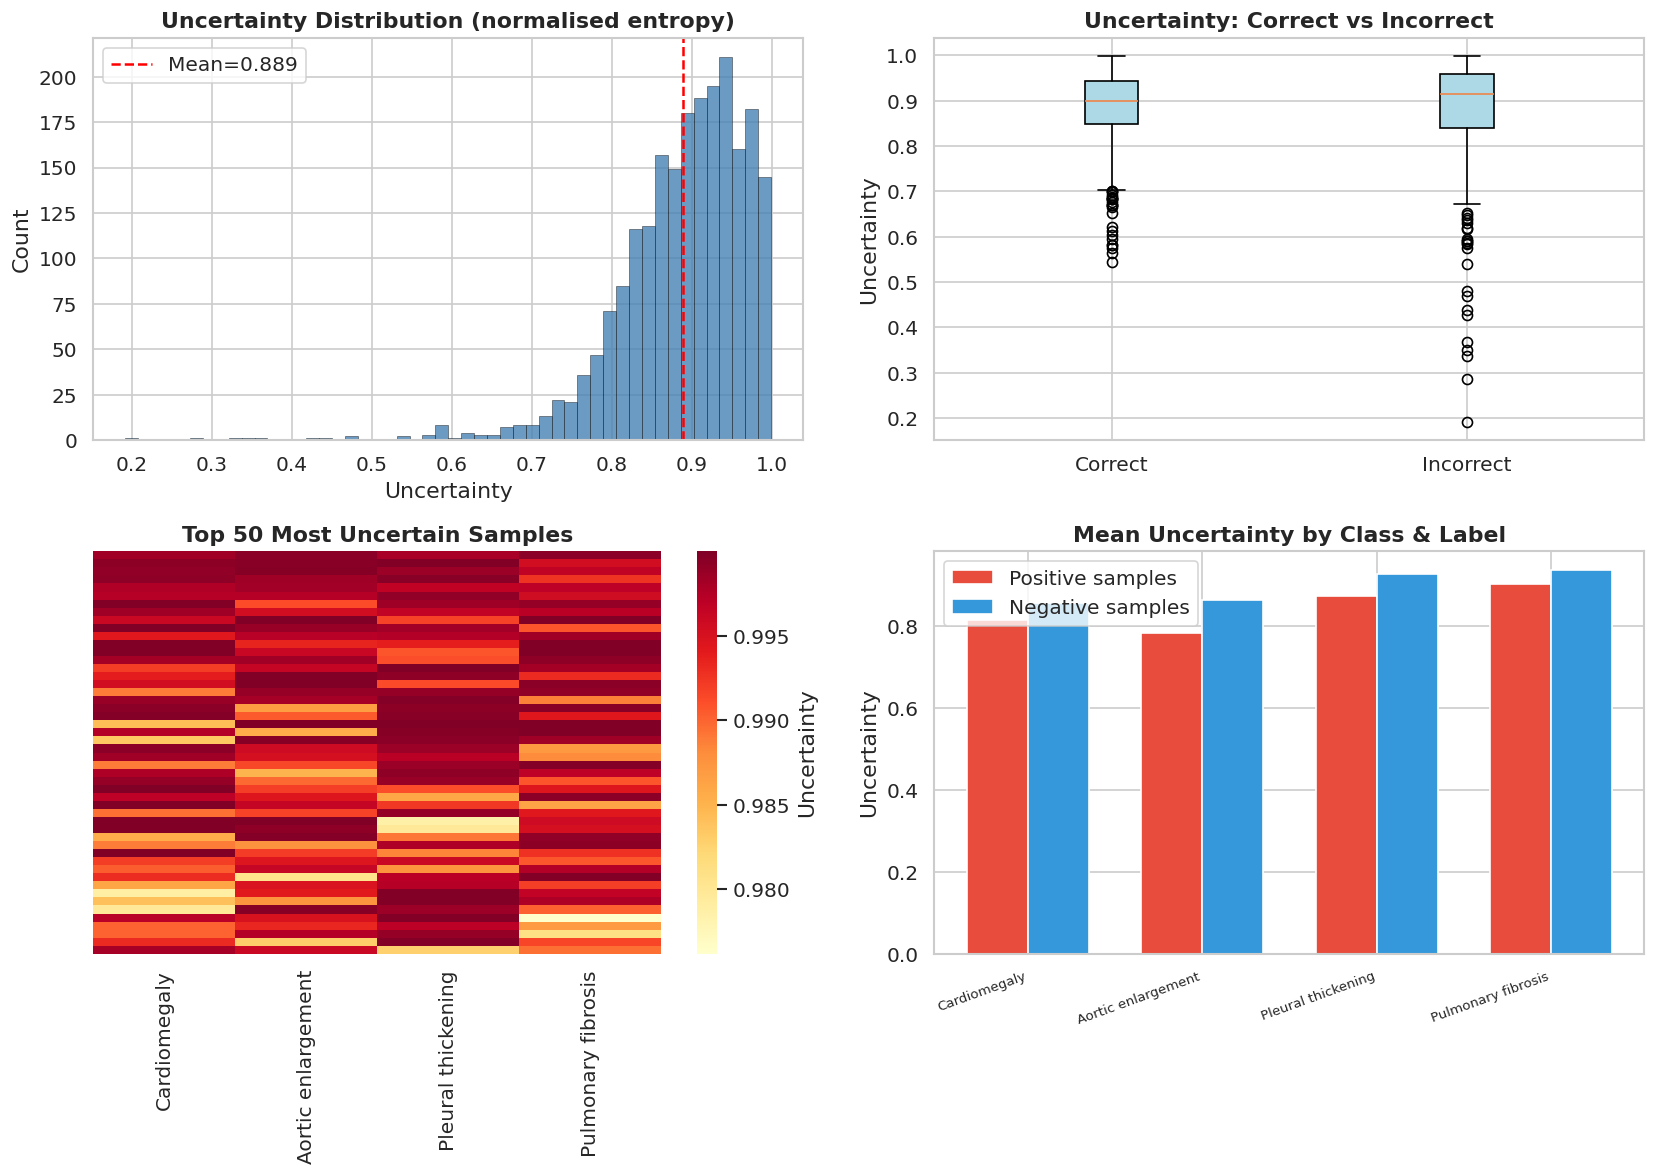

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Uncertainty distribution
axes[0, 0].hist(uncertainty, bins=50, color="steelblue", edgecolor="black", linewidth=0.3, alpha=0.8)
axes[0, 0].axvline(uncertainty.mean(), color="red", linestyle="--", label=f"Mean={uncertainty.mean():.3f}")
axes[0, 0].set_title("Uncertainty Distribution (normalised entropy)", fontweight="bold")
axes[0, 0].set_xlabel("Uncertainty")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend()

# 2. Uncertainty vs correctness
# "Correct" for multilabel: all labels match
correct = (y_pred == y_true).all(axis=1)
axes[0, 1].boxplot([uncertainty[correct], uncertainty[~correct]],
                    labels=["Correct", "Incorrect"], patch_artist=True,
                    boxprops=dict(facecolor="lightblue"))
axes[0, 1].set_title("Uncertainty: Correct vs Incorrect", fontweight="bold")
axes[0, 1].set_ylabel("Uncertainty")

# 3. Per-class uncertainty heatmap (sorted by mean uncertainty)
class_entropy = entropy_per_class / max_entropy  # normalised per-class
# Show top 50 most uncertain samples
top_uncertain_idx = np.argsort(uncertainty)[-50:][::-1]
heatmap_data = class_entropy[top_uncertain_idx]
sns.heatmap(heatmap_data, ax=axes[1, 0], cmap="YlOrRd",
            xticklabels=DISEASE_COLS, yticklabels=False, cbar_kws={"label": "Uncertainty"})
axes[1, 0].set_title("Top 50 Most Uncertain Samples", fontweight="bold")
axes[1, 0].set_xlabel("")

# 4. Uncertainty per class
class_uncertainties = []
for i, cls in enumerate(DISEASE_COLS):
    pos_mask = y_true[:, i] == 1
    neg_mask = y_true[:, i] == 0
    class_uncertainties.append({
        "class": cls,
        "positive_mean": float(class_entropy[pos_mask, i].mean()) if pos_mask.any() else 0,
        "negative_mean": float(class_entropy[neg_mask, i].mean()) if neg_mask.any() else 0,
    })

cu_df = pd.DataFrame(class_uncertainties)
x_pos = np.arange(len(DISEASE_COLS))
width = 0.35
axes[1, 1].bar(x_pos - width/2, cu_df["positive_mean"], width, label="Positive samples", color="#e74c3c")
axes[1, 1].bar(x_pos + width/2, cu_df["negative_mean"], width, label="Negative samples", color="#3498db")
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(DISEASE_COLS, rotation=20, ha="right", fontsize=8)
axes[1, 1].set_title("Mean Uncertainty by Class & Label", fontweight="bold")
axes[1, 1].set_ylabel("Uncertainty")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "uncertainty_analysis.png"), bbox_inches="tight", dpi=150)
plt.show()

### 6.1 Uncertainty Heatmap on Most Uncertain Samples

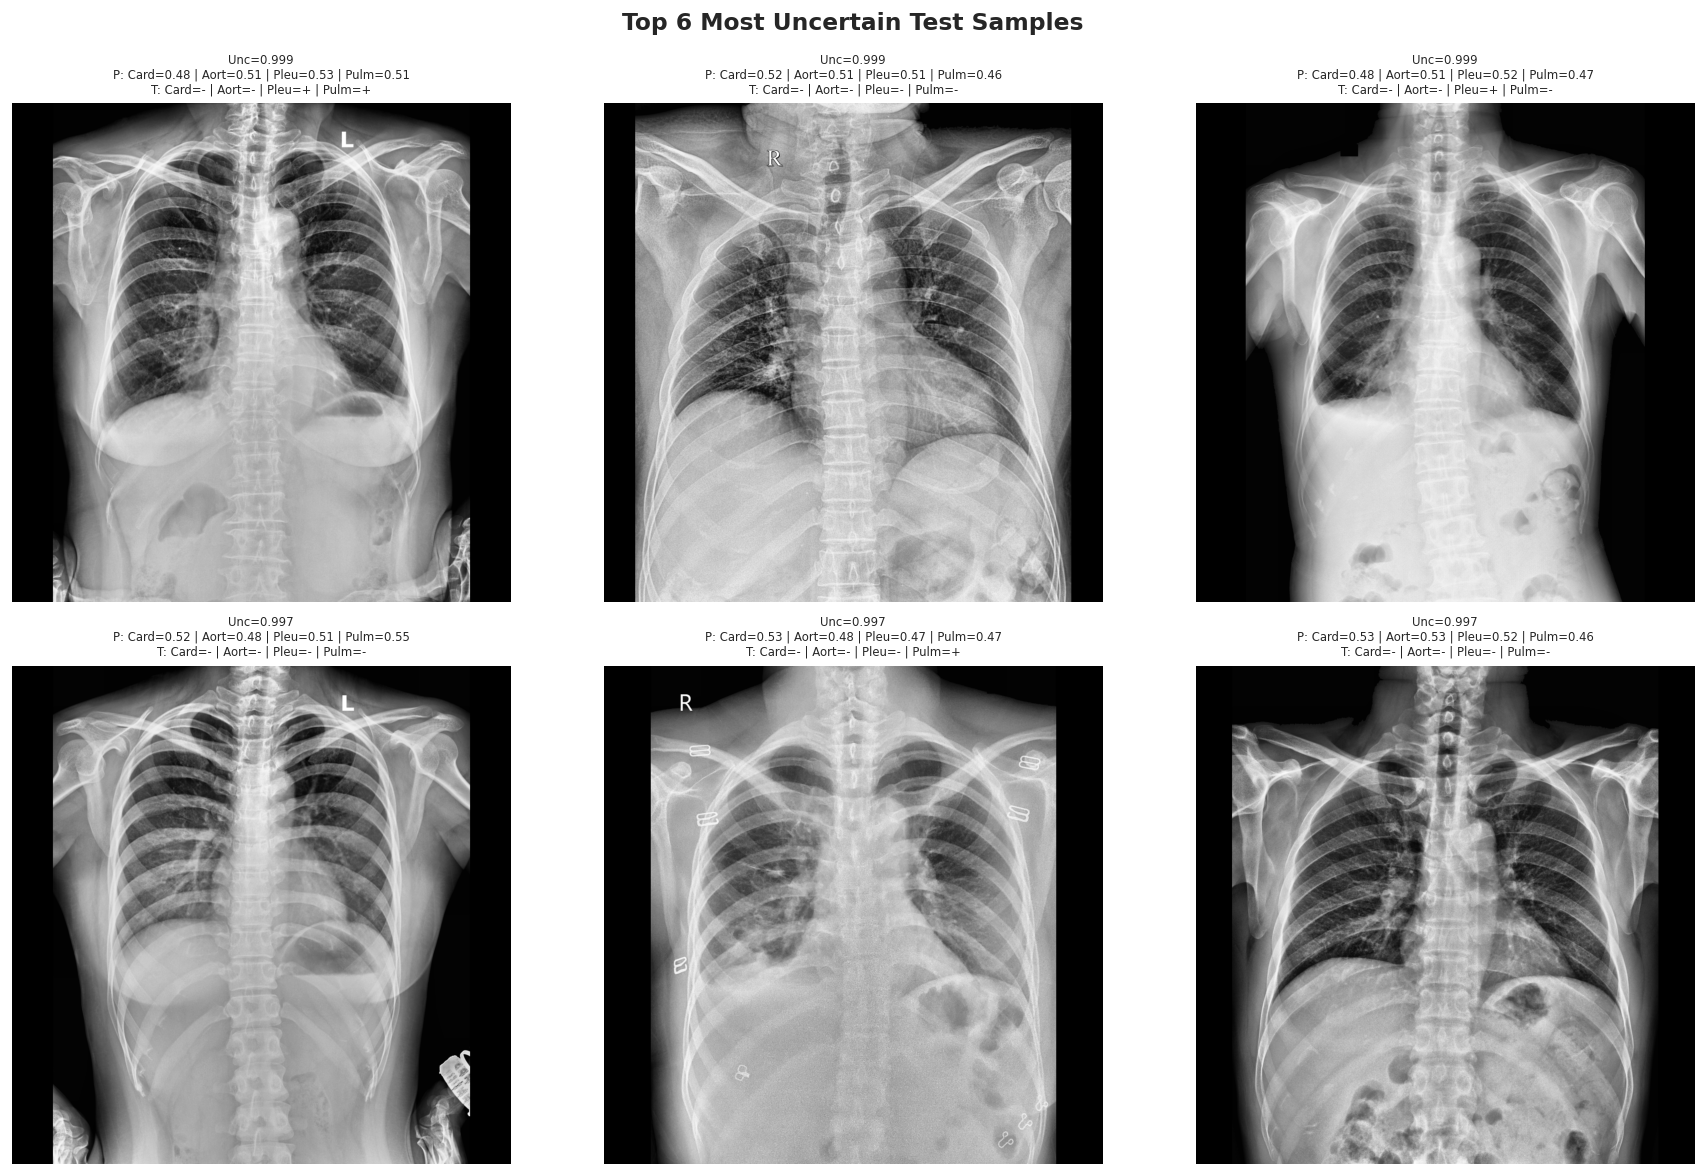

In [13]:
# Show top 6 most uncertain test images with their probabilities
top6_idx = np.argsort(uncertainty)[-6:][::-1]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

test_files = data_module.test_dataset.df["filepath_processed"].tolist()

for ax_idx, sample_idx in enumerate(top6_idx):
    filepath = test_files[sample_idx]
    img = load_processed_image(filepath)
    if img is not None:
        axes[ax_idx].imshow(img)
    
    probs_str = " | ".join([f"{cls[:4]}={y_probs[sample_idx, i]:.2f}" for i, cls in enumerate(DISEASE_COLS)])
    true_str = " | ".join([f"{cls[:4]}={'+'if y_true[sample_idx, i]==1 else '-'}" for i, cls in enumerate(DISEASE_COLS)])
    axes[ax_idx].set_title(f"Unc={uncertainty[sample_idx]:.3f}\nP: {probs_str}\nT: {true_str}", fontsize=7)
    axes[ax_idx].axis("off")

fig.suptitle("Top 6 Most Uncertain Test Samples", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "uncertain_samples.png"), bbox_inches="tight", dpi=150)
plt.show()

## 7. Failure Analysis
Examine false positives and false negatives per class.

           Disease  TP  FP  FN   TN  Sensitivity  Specificity   PPV   NPV
      Cardiomegaly 153 166 119 1714        0.562        0.912 0.480 0.935
Aortic enlargement 220 141 132 1659        0.625        0.922 0.609 0.926
Pleural thickening  34  56  98 1964        0.258        0.972 0.378 0.952
Pulmonary fibrosis  21  36 131 1964        0.138        0.982 0.368 0.937


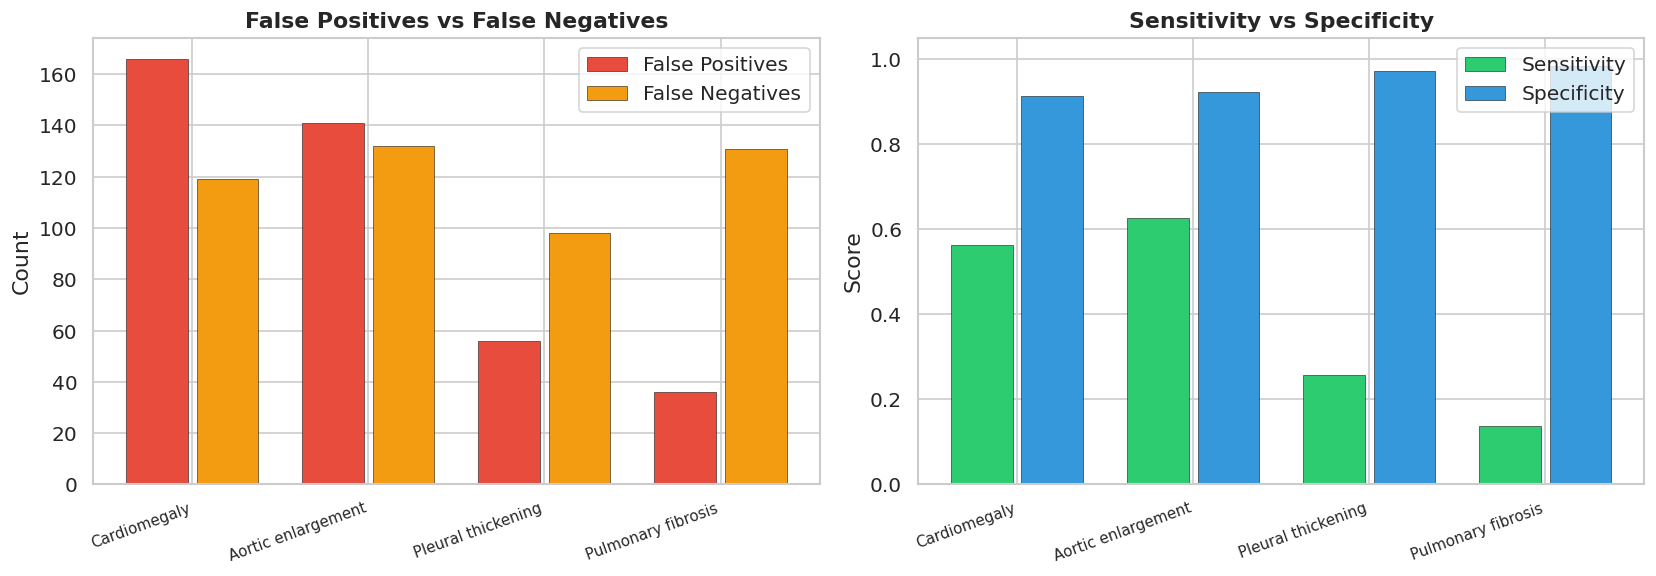

In [14]:
# Per-class FP/FN analysis
failure_data = []
for i, cls in enumerate(DISEASE_COLS):
    tp = int(((y_pred[:, i] == 1) & (y_true[:, i] == 1)).sum())
    fp = int(((y_pred[:, i] == 1) & (y_true[:, i] == 0)).sum())
    fn = int(((y_pred[:, i] == 0) & (y_true[:, i] == 1)).sum())
    tn = int(((y_pred[:, i] == 0) & (y_true[:, i] == 0)).sum())
    failure_data.append({
        "Disease": cls, "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "Sensitivity": tp/(tp+fn+1e-8), "Specificity": tn/(tn+fp+1e-8),
        "PPV": tp/(tp+fp+1e-8), "NPV": tn/(tn+fn+1e-8),
    })

failure_df = pd.DataFrame(failure_data)
print(failure_df[["Disease", "TP", "FP", "FN", "TN", "Sensitivity", "Specificity", "PPV", "NPV"]].round(3).to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# FP vs FN
x_pos = np.arange(len(DISEASE_COLS))
ax1.bar(x_pos - 0.2, failure_df["FP"], 0.35, label="False Positives", color="#e74c3c", edgecolor="black", linewidth=0.3)
ax1.bar(x_pos + 0.2, failure_df["FN"], 0.35, label="False Negatives", color="#f39c12", edgecolor="black", linewidth=0.3)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(DISEASE_COLS, rotation=20, ha="right", fontsize=9)
ax1.set_ylabel("Count")
ax1.set_title("False Positives vs False Negatives", fontweight="bold")
ax1.legend()

# Sensitivity vs Specificity
ax2.bar(x_pos - 0.2, failure_df["Sensitivity"], 0.35, label="Sensitivity", color="#2ecc71", edgecolor="black", linewidth=0.3)
ax2.bar(x_pos + 0.2, failure_df["Specificity"], 0.35, label="Specificity", color="#3498db", edgecolor="black", linewidth=0.3)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(DISEASE_COLS, rotation=20, ha="right", fontsize=9)
ax2.set_ylabel("Score")
ax2.set_title("Sensitivity vs Specificity", fontweight="bold")
ax2.legend()
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "failure_analysis.png"), bbox_inches="tight", dpi=150)
plt.show()

### 7.1 High-Confidence Errors

In [15]:
# Find predictions where model was very confident but wrong
high_conf_errors = []
for i, cls in enumerate(DISEASE_COLS):
    # High-confidence false positives (model says disease but ground truth is normal)
    fp_mask = (y_pred[:, i] == 1) & (y_true[:, i] == 0)
    fp_probs = y_probs[fp_mask, i]
    if len(fp_probs) > 0:
        for prob in fp_probs[fp_probs > 0.8]:
            high_conf_errors.append({"type": "FP", "class": cls, "prob": prob})
    
    # High-confidence false negatives (model says normal but ground truth is disease)
    fn_mask = (y_pred[:, i] == 0) & (y_true[:, i] == 1)
    fn_probs = y_probs[fn_mask, i]
    if len(fn_probs) > 0:
        for prob in fn_probs[fn_probs < 0.2]:
            high_conf_errors.append({"type": "FN", "class": cls, "prob": prob})

hce_df = pd.DataFrame(high_conf_errors)
if len(hce_df) > 0:
    print(f"High-confidence errors: {len(hce_df)}")
    print(hce_df.groupby(["type", "class"]).size().reset_index(name="count").to_string(index=False))
else:
    print("No high-confidence errors found (prob > 0.8 for FP or prob < 0.2 for FN)")

High-confidence errors: 124
type              class  count
  FN Aortic enlargement      3
  FN       Cardiomegaly      1
  FP Aortic enlargement     36
  FP       Cardiomegaly     45
  FP Pleural thickening     26
  FP Pulmonary fibrosis     13


## 8. Threshold Sensitivity

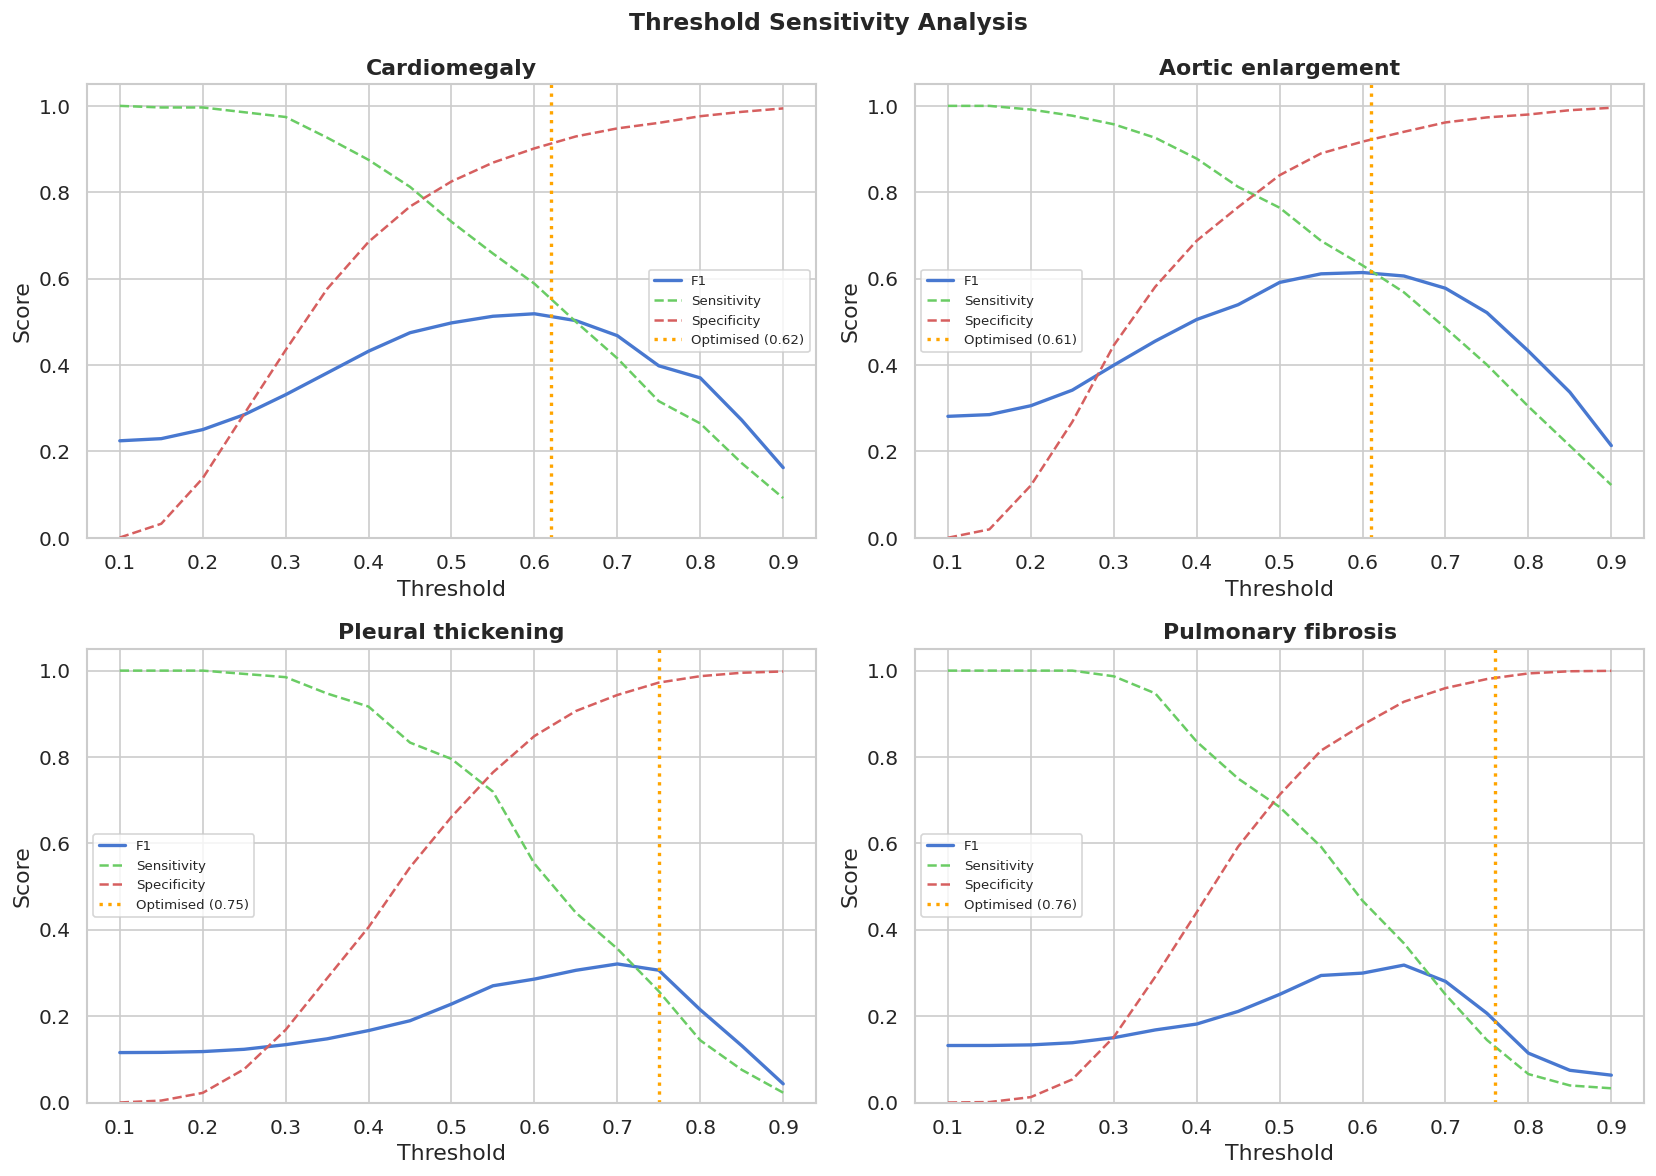

In [16]:
thresholds_range = np.arange(0.1, 0.95, 0.05)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, cls in enumerate(DISEASE_COLS):
    ax = axes[i // 2, i % 2]
    f1_scores = []
    sens_scores = []
    spec_scores = []
    
    for t in thresholds_range:
        preds_t = (y_probs[:, i] >= t).astype(int)
        f1_val = f1_score(y_true[:, i], preds_t, zero_division=0)
        tp = ((preds_t == 1) & (y_true[:, i] == 1)).sum()
        fn = ((preds_t == 0) & (y_true[:, i] == 1)).sum()
        tn = ((preds_t == 0) & (y_true[:, i] == 0)).sum()
        fp = ((preds_t == 1) & (y_true[:, i] == 0)).sum()
        
        f1_scores.append(f1_val)
        sens_scores.append(tp / (tp + fn + 1e-8))
        spec_scores.append(tn / (tn + fp + 1e-8))
    
    ax.plot(thresholds_range, f1_scores, "b-", lw=2, label="F1")
    ax.plot(thresholds_range, sens_scores, "g--", lw=1.5, label="Sensitivity")
    ax.plot(thresholds_range, spec_scores, "r--", lw=1.5, label="Specificity")
    
    opt_thresh = THRESHOLDS[cls]
    ax.axvline(opt_thresh, color="orange", linestyle=":", lw=2, label=f"Optimised ({opt_thresh:.2f})")
    
    ax.set_title(f"{cls}", fontweight="bold")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.legend(fontsize=8, loc="best")
    ax.set_ylim([0, 1.05])

fig.suptitle("Threshold Sensitivity Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "threshold_sensitivity.png"), bbox_inches="tight", dpi=150)
plt.show()

## 9. Evaluation Summary

In [17]:
macro_auc_final = roc_auc_score(y_true, y_probs, average="macro")
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
subset_acc = accuracy_score(y_true, y_pred)  # exact match for multilabel

print("=" * 60)
print("EVALUATION SUMMARY — ConvNeXt Small")
print("=" * 60)
print(f"  Test samples      : {len(y_true):,}")
print(f"  Macro AUC         : {macro_auc_final:.4f}")
print(f"  Macro F1          : {macro_f1:.4f}")
print(f"  Subset Accuracy   : {subset_acc:.4f}")
print(f"  Mean Uncertainty  : {uncertainty.mean():.4f}")
print()
print("Per-class performance:")
for i, cls in enumerate(DISEASE_COLS):
    cls_auc = roc_auc_score(y_true[:, i], y_probs[:, i])
    cls_f1 = f1_score(y_true[:, i], y_pred[:, i], zero_division=0)
    print(f"  {cls:25s}: AUC={cls_auc:.3f}  F1={cls_f1:.3f}  Thresh={THRESHOLDS[cls]:.2f}")
print()
print("Plots saved to:", OUTPUT_DIR)
print("=" * 60)

EVALUATION SUMMARY — ConvNeXt Small
  Test samples      : 2,152
  Macro AUC         : 0.8255
  Macro F1          : 0.4105
  Subset Accuracy   : 0.7361
  Mean Uncertainty  : 0.8889

Per-class performance:
  Cardiomegaly             : AUC=0.865  F1=0.518  Thresh=0.62
  Aortic enlargement       : AUC=0.877  F1=0.617  Thresh=0.61
  Pleural thickening       : AUC=0.800  F1=0.306  Thresh=0.75
  Pulmonary fibrosis       : AUC=0.760  F1=0.201  Thresh=0.76

Plots saved to: /home/karim-mache/Documents/nouncode-ai/portfolio_projects/xclinvision-ops/outputs/evaluation
